In [ ]:
!unzip Early_Sepsis_Alert.zip -d /content/extracted_folder

Archive:  Early_Sepsis_Alert.zip
   creating: /content/extracted_folder/Early_Sepsis_Alert/
  inflating: /content/extracted_folder/Early_Sepsis_Alert/.DS_Store  
  inflating: /content/extracted_folder/__MACOSX/Early_Sepsis_Alert/._.DS_Store  
   creating: /content/extracted_folder/Early_Sepsis_Alert/Data/
   creating: /content/extracted_folder/Early_Sepsis_Alert/notebooks/
  inflating: /content/extracted_folder/Early_Sepsis_Alert/Data/.DS_Store  
  inflating: /content/extracted_folder/__MACOSX/Early_Sepsis_Alert/Data/._.DS_Store  
   creating: /content/extracted_folder/Early_Sepsis_Alert/Data/External/
   creating: /content/extracted_folder/Early_Sepsis_Alert/Data/Processed Data/
   creating: /content/extracted_folder/Early_Sepsis_Alert/Data/Raw Data/
  inflating: /content/extracted_folder/Early_Sepsis_Alert/notebooks/01_data_exploration.ipynb  
  inflating: /content/extracted_folder/__MACOSX/Early_Sepsis_Alert/notebooks/._01_data_exploration.ipynb  
  inflating: /content/extracted_fol

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



# 01 — Data Exploration
## Early Sepsis Alert — ICU Vital Sign Time-Series

**Goal:** Predict sepsis / acute organ failure onset 6–12 hours before it happens,
using hourly vital sign time-series per ICU patient.

This notebook explores:
- Row-level vs patient-level target imbalance
- ICU stay length distribution
- Time-to-sepsis-onset (critical for defining the prediction horizon)
- Vital sign trajectories leading up to sepsis onset vs non-sepsis patients
- Missingness, correlations, outliers



# Cell 2 — Imports & config


In [23]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 50)

DATA_DIR = Path("../data/processed")
REPORTS_DIR = Path("../reports")
REPORTS_DIR.mkdir(exist_ok=True, parents=True)

TARGET_COL = "SepsisLabel"
ID_COL = "patient_id"
TIME_COL = "HourInStay"


# Cell 3 — Load data

In [24]:
from pathlib import Path

DATA_DIR = Path("/content/extracted_folder/Early_Sepsis_Alert/Data/Processed Data")

train = pd.read_csv('/content/extracted_folder/Early_Sepsis_Alert/data/processed/train.csv')
test = pd.read_csv('/content/extracted_folder/Early_Sepsis_Alert/data/processed/test.csv')
features_meta = pd.read_csv('/content/extracted_folder/Early_Sepsis_Alert/data/processed/features.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train patients:", train[ID_COL].nunique())
print("Test patients:", test[ID_COL].nunique())

train.head()

Train shape: (46482, 43)
Test shape: (11894, 43)
Train patients: 1226
Test patients: 307


,patient_id,HourInStay,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,FiO2,pH,PaCO2,SaO2,AST,BUN,Alkalinephos,Calcium,Chloride,Creatinine,Bilirubin_direct,Glucose,Lactate,Magnesium,Phosphate,Potassium,Bilirubin_total,TroponinI,Hct,Hgb,PTT,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,1,1,61.0,99.0,36.44,124.0,65.0,43.0,17.5,0.0,0.0,22.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,7.9,113.0,2.5,0.0,78.0,0.0,2.5,4.4,5.1,0.0,0.0,27.8,9.7,0.0,11.0,0.0,158.0,75.91,0,0.0,1.0,-98.6,2,0
1,1,2,64.0,98.0,36.44,125.0,64.0,41.0,27.0,0.0,0.0,22.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,7.9,113.0,2.5,0.0,78.0,0.0,2.5,4.4,5.1,0.0,0.0,27.8,9.7,0.0,11.0,0.0,158.0,75.91,0,0.0,1.0,-98.6,3,0
2,1,3,56.0,100.0,36.44,123.0,65.0,41.0,9.0,0.0,0.0,22.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,7.9,113.0,2.5,0.0,78.0,0.0,2.5,4.4,5.1,0.0,0.0,27.8,9.7,0.0,11.0,0.0,158.0,75.91,0,0.0,1.0,-98.6,4,0
3,1,4,66.0,99.0,36.22,120.0,67.0,43.0,23.0,0.0,0.0,22.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,7.9,113.0,2.5,0.0,78.0,0.0,2.5,4.4,5.1,0.0,0.0,27.8,9.7,0.0,11.0,0.0,158.0,75.91,0,0.0,1.0,-98.6,5,0
4,1,5,94.0,100.0,36.22,194.0,116.0,66.0,14.0,0.0,0.0,22.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,7.9,113.0,2.5,0.0,78.0,0.0,2.5,4.4,5.1,0.0,0.0,27.8,9.7,0.0,11.0,0.0,158.0,75.91,0,0.0,1.0,-98.6,6,0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Cell 4 — Basic schema check

In [25]:
print("\nAny missing values?")
print(train.isna().sum().sum(), "in train |", test.isna().sum().sum(), "in test")

feature_cols = [c for c in train.columns if c not in [ID_COL, TIME_COL, TARGET_COL]]
print(f"\n{len(feature_cols)} feature columns:")
print(feature_cols)


Any missing values?
0 in train | 0 in test

40 feature columns:
['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS']


## 1. Target Distribution
Row-level labels are hour-by-hour sepsis flags. Patient-level tells us
how many patients ever developed sepsis during their stay — this is the
number that matters for clinical framing.

# Cell 6 — Row-level vs patient-level imbalance

Row-level sepsis rate (train): 2.2460%
Patient-level sepsis rate (train): 9.0538%
Sepsis patients: 111 / 1226


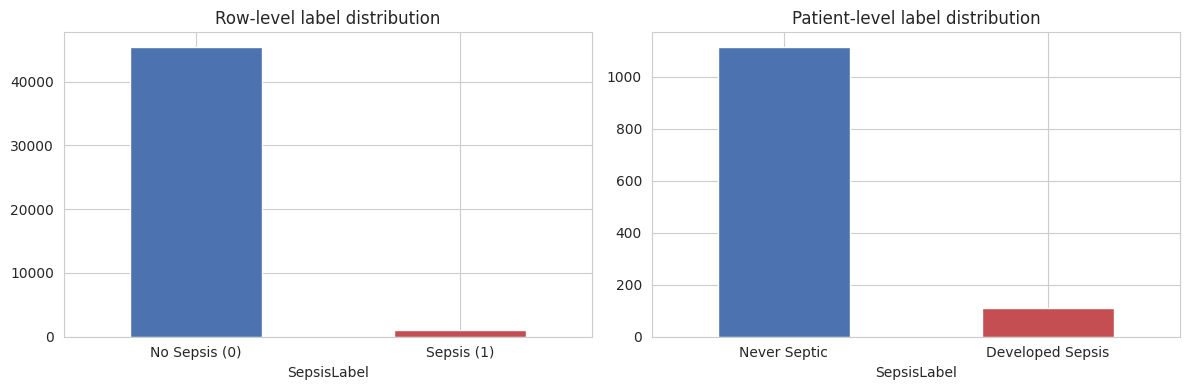

In [27]:
ate = train[TARGET_COL].mean()
patient_labels = train.groupby(ID_COL)[TARGET_COL].max()
patient_rate = patient_labels.mean()

print(f"Row-level sepsis rate (train): {ate:.4%}")
print(f"Patient-level sepsis rate (train): {patient_rate:.4%}")
print(f"Sepsis patients: {patient_labels.sum()} / {len(patient_labels)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train[TARGET_COL].value_counts().plot(kind="bar", ax=axes[0], color=["#4C72B0", "#C44E52"])
axes[0].set_title("Row-level label distribution")
axes[0].set_xticklabels(["No Sepsis (0)", "Sepsis (1)"], rotation=0)

patient_labels.value_counts().plot(kind="bar", ax=axes[1], color=["#4C72B0", "#C44E52"])
axes[1].set_title("Patient-level label distribution")
axes[1].set_xticklabels(["Never Septic", "Developed Sepsis"], rotation=0)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "target_distribution.png", dpi=120)
plt.show()

## 2. ICU Stay Length Distribution

count    1226.000000
mean       37.913540
std        22.931857
min         7.000000
25%        23.000000
50%        37.000000
75%        46.000000
max       264.000000
Name: HourInStay, dtype: float64


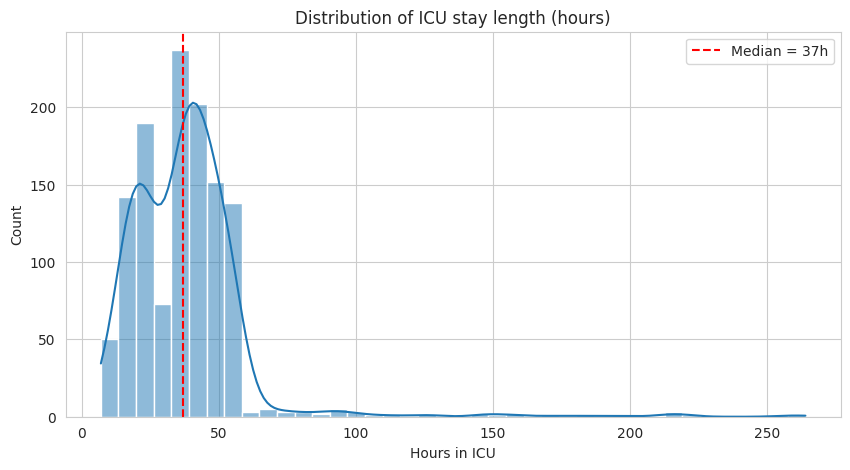

In [28]:
stay_length = train.groupby(ID_COL)[TIME_COL].max()
print(stay_length.describe())

plt.figure()
sns.histplot(stay_length, bins=40, kde=True)
plt.axvline(stay_length.median(), color="red", linestyle="--", label=f"Median = {stay_length.median():.0f}h")
plt.title("Distribution of ICU stay length (hours)")
plt.xlabel("Hours in ICU")
plt.legend()
plt.savefig(REPORTS_DIR / "stay_length_distribution.png", dpi=120)
plt.show()

## 3. Time-to-Sepsis-Onset

This is the most important analysis for defining the prediction horizon.
We need to know: at what hour (relative to ICU admission) does sepsis
typically first get flagged, and how much runway do we realistically have
to predict it 6–12h in advance?

# Cell 10 — First sepsis onset hour per patient

count    111.000000
mean      51.405405
std       60.725070
min        1.000000
25%        6.500000
50%       30.000000
75%       75.500000
max      256.000000
Name: HourInStay, dtype: float64


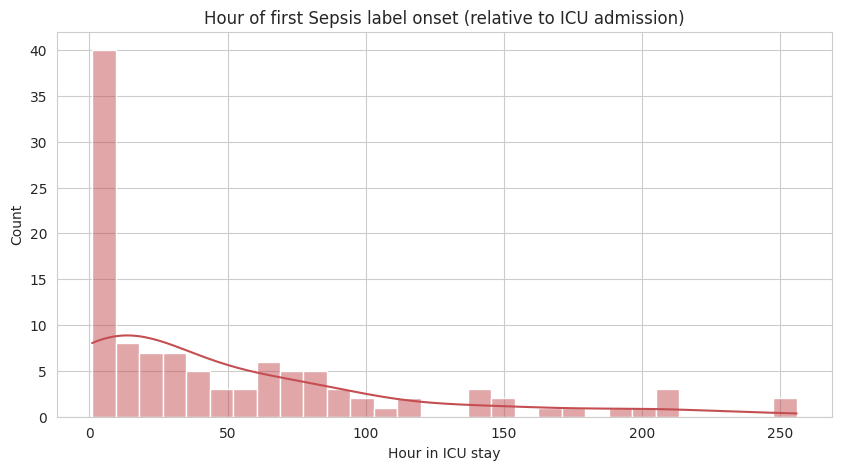

% of septic patients with onset < 12h into stay: 36.94%


In [32]:
septic_patients = train[train[TARGET_COL] == 1]
onset_hour = septic_patients.groupby(ID_COL)[TIME_COL].min()

print(onset_ho.describe())

plt.figure()
sns.histplot(onset_ho, bins=30, kde=True, color="#C44E52")
plt.title("Hour of first Sepsis label onset (relative to ICU admission)")
plt.xlabel("Hour in ICU stay")
plt.savefig(REPORTS_DIR / "sepsis_onset_hour.png", dpi=120)
plt.show()

# Sanity check: how many patients have onset before hour 12?
# (limits how much "lead time" data exists for very early admissions)
early_onset_pct = (onset_ho < 12).mean()
print(f"% of septic patients with onset < 12h into stay: {early_onset_pct:.2%}")

## 4. Vital Sign Trajectories: Septic vs Non-Septic

Align septic patients' data to hours-relative-to-onset (t=0 is onset hour),
and compare against a random sample of non-septic patients' full trajectories.
This tells us which vitals show early warning signal before onset —
directly informs feature engineering (sliding windows, deltas, slopes).
"""

# Cell 12 — Build hours-relative-to-onset for septic patients

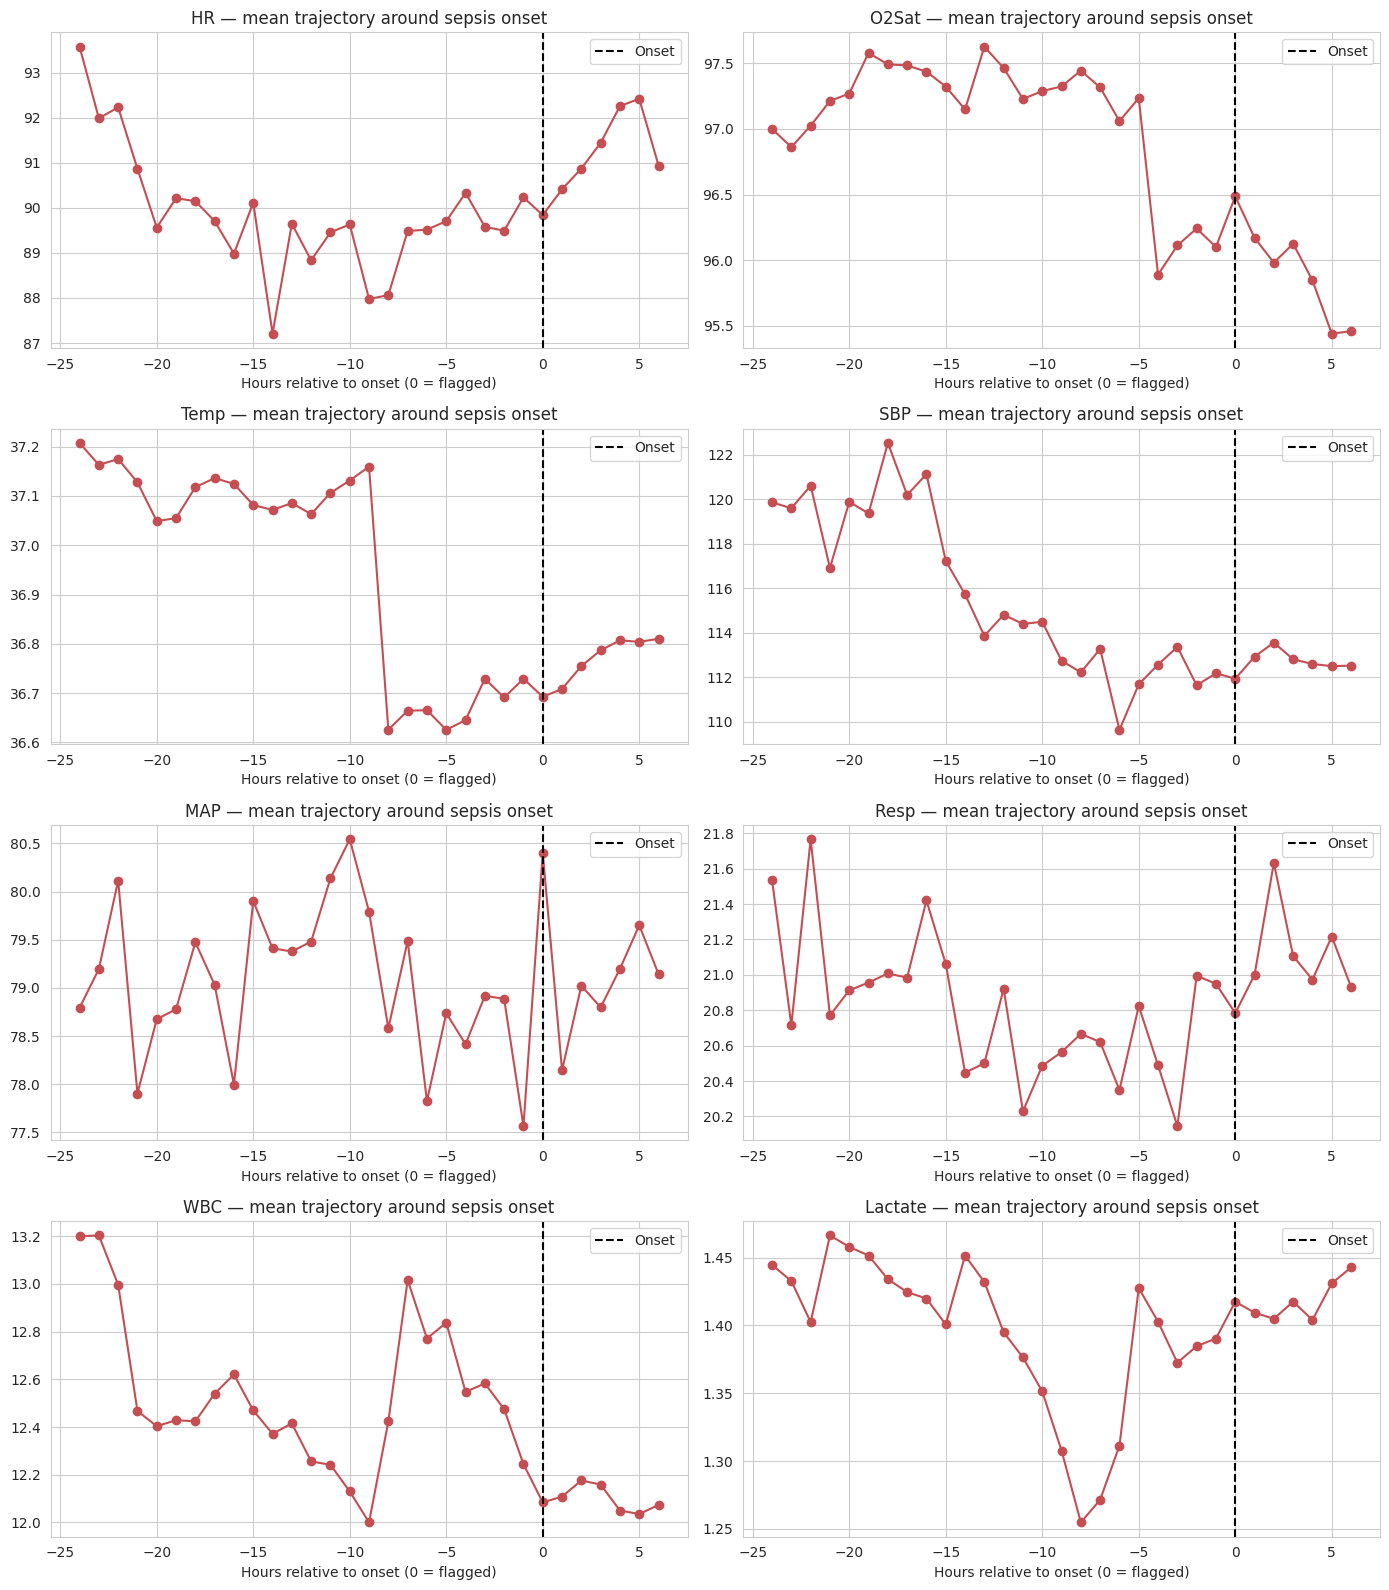

In [33]:

key_vitals = ["HR", "O2Sat", "Temp", "SBP", "MAP", "Resp", "WBC", "Lactate"]

onset_map = onset_hour.to_dict()
septic_ids = list(onset_map.keys())

traj = train[train[ID_COL].isin(septic_ids)].copy()
traj["hours_to_onset"] = traj.apply(lambda r: r[TIME_COL] - onset_map[r[ID_COL]], axis=1)

# Keep window -24h to +6h around onset
window = traj[(traj["hours_to_onset"] >= -24) & (traj["hours_to_onset"] <= 6)]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
for ax, vital in zip(axes.flat, key_vitals):
    grp = window.groupby("hours_to_onset")[vital].mean()
    ax.plot(grp.index, grp.values, marker="o", color="#C44E52")
    ax.axvline(0, color="black", linestyle="--", label="Onset")
    ax.set_title(f"{vital} — mean trajectory around sepsis onset")
    ax.set_xlabel("Hours relative to onset (0 = flagged)")
    ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "vital_trajectories_pre_onset.png", dpi=120)
plt.show()


# Cell 13 — Non-septic patient baseline for comparison

In [34]:
non_septic_ids = train.loc[~train[ID_COL].isin(septic_ids), ID_COL].unique()
sample_ids = np.random.RandomState(42).choice(non_septic_ids, size=min(300, len(non_septic_ids)), replace=False)
baseline = train[train[ID_COL].isin(sample_ids)]

comparison = pd.DataFrame({
    "vital": key_vitals,
    "mean_non_septic": [baseline[v].mean() for v in key_vitals],
    "mean_septic_at_onset": [window[window["hours_to_onset"] == 0][v].mean() for v in key_vitals],
    "mean_septic_6h_before": [window[window["hours_to_onset"] == -6][v].mean() for v in key_vitals],
})
comparison["delta_6h_before_vs_baseline"] = comparison["mean_septic_6h_before"] - comparison["mean_non_septic"]
comparison

,vital,mean_non_septic,mean_septic_at_onset,mean_septic_6h_before,delta_6h_before_vs_baseline
0,HR,83.594358,89.842342,89.518072,5.923714
1,O2Sat,97.006114,96.486486,97.060241,0.054127
2,Temp,36.552866,36.692523,36.665301,0.112435
3,SBP,120.421264,111.930180,109.626506,-10.794758
4,MAP,78.491738,80.402162,77.823373,-0.668364
5,Resp,18.404872,20.783784,20.349398,1.944526
6,WBC,10.530584,12.083784,12.771084,2.240500
7,Lactate,0.761872,1.417568,1.311446,0.549574


## 5. Missingness & Zero-Inflation Check

Some vitals (e.g. EtCO2, Bilirubin_direct) may be structurally sparse
(rarely measured unless clinically indicated). Zero-inflation here likely
means "not measured" rather than a true physiological zero — important
for feature engineering (e.g. add `_was_measured` flags).

# Cell 15

EtCO2               1.000000
TroponinI           0.971666
Bilirubin_direct    0.966611
Fibrinogen          0.835872
Unit2               0.739405
Unit1               0.726819
Alkalinephos        0.685211
Bilirubin_total     0.681683
AST                 0.677208
SaO2                0.553117
Lactate             0.524547
BaseExcess          0.498300
Gender              0.420744
FiO2                0.357794
PaCO2               0.322211
dtype: float64


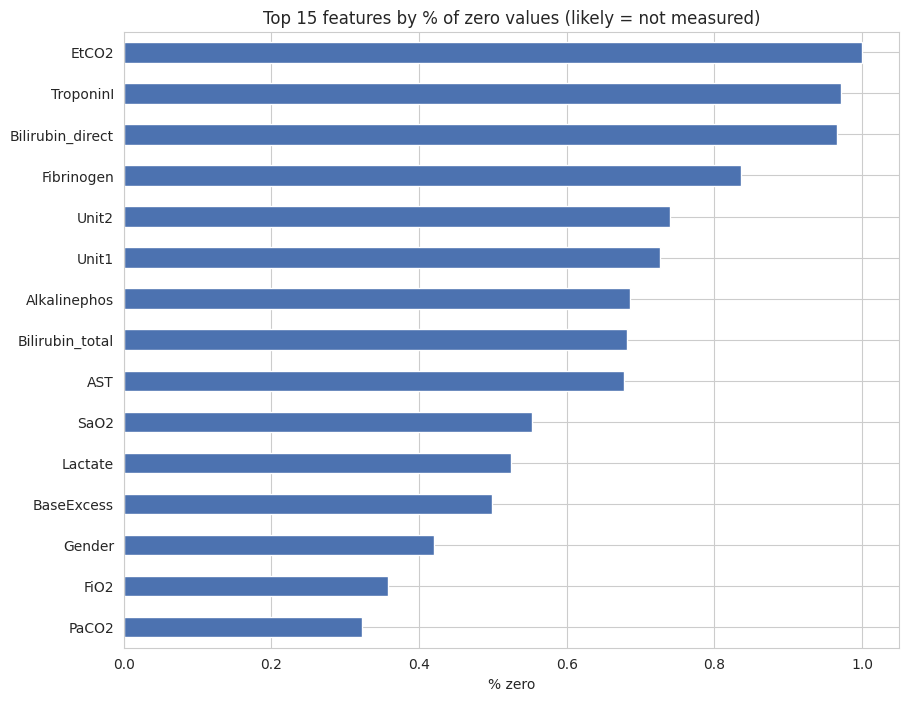

In [35]:
zero_pct = (train[feature_cols] == 0).mean().sort_values(ascending=False)
print(zero_pct.head(15))

plt.figure(figsize=(10, 8))
zero_pct.head(15).plot(kind="barh", color="#4C72B0")
plt.title("Top 15 features by % of zero values (likely = not measured)")
plt.xlabel("% zero")
plt.gca().invert_yaxis()
plt.savefig(REPORTS_DIR / "zero_inflation.png", dpi=120)
plt.show()

## 6. Correlation Structure

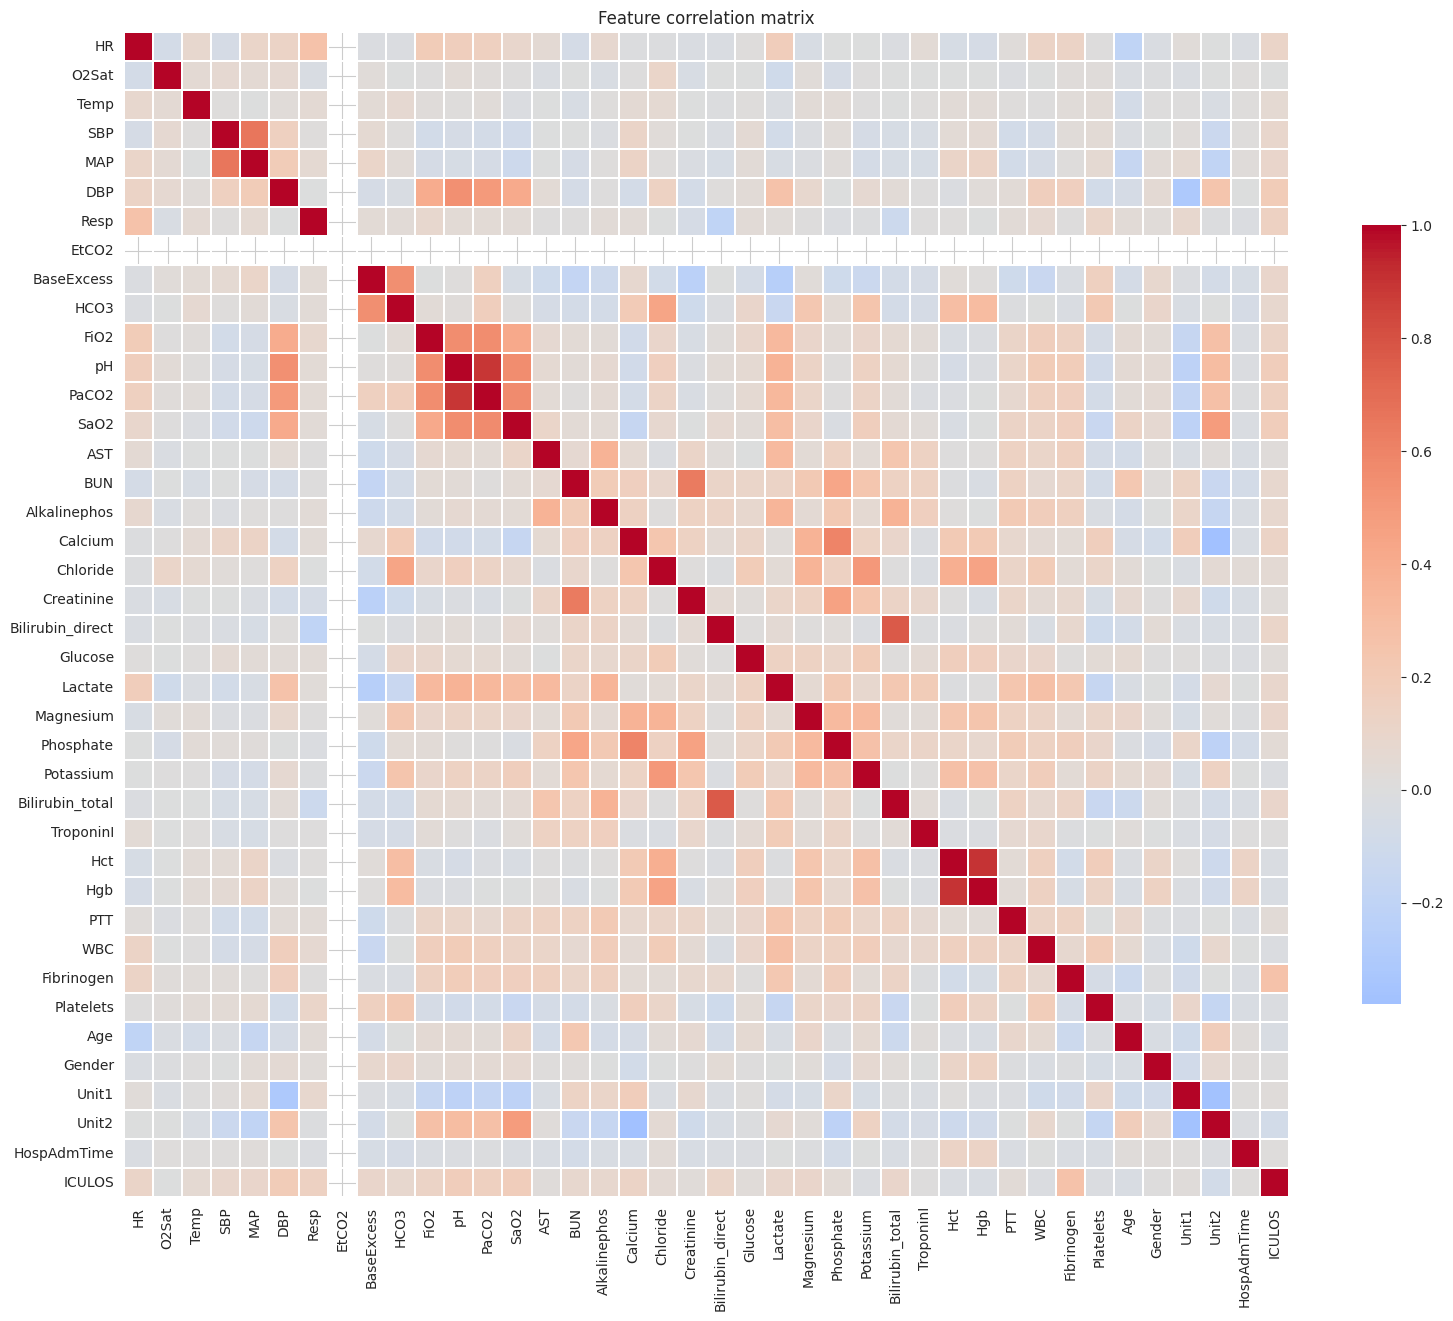

ICULOS         0.161402
Hct           -0.069417
Hgb           -0.068563
Resp           0.065854
pH             0.061474
PaCO2          0.058038
HR             0.054669
Lactate        0.053460
HospAdmTime   -0.050459
SBP           -0.049139
FiO2           0.048751
Chloride      -0.047264
Unit2         -0.046327
Creatinine     0.040428
Glucose       -0.037104
Name: SepsisLabel, dtype: float64


In [36]:
numeric_cols = [c for c in feature_cols if train[c].dtype != "object"]
corr = train[numeric_cols].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3, square=True,
            cbar_kws={"shrink": 0.6})
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "correlation_matrix.png", dpi=120)
plt.show()

# Correlation of each feature with target (row-level, informative but noisy)
target_corr = train[numeric_cols + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL).sort_values(key=abs, ascending=False)
print(target_corr.head(15))

## 7. Demographics (Age / Gender) vs Sepsis

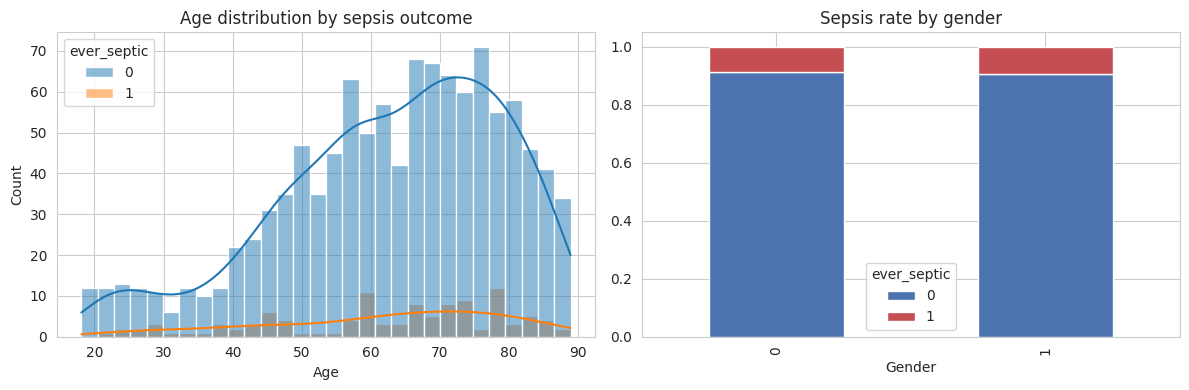

In [37]:
demo = train.groupby(ID_COL).agg(
    Age=("Age", "first"),
    Gender=("Gender", "first"),
    ever_septic=(TARGET_COL, "max")
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=demo, x="Age", hue="ever_septic", kde=True, ax=axes[0], bins=30)
axes[0].set_title("Age distribution by sepsis outcome")

pd.crosstab(demo["Gender"], demo["ever_septic"], normalize="index").plot(
    kind="bar", stacked=True, ax=axes[1], color=["#4C72B0", "#C44E52"]
)
axes[1].set_title("Sepsis rate by gender")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "demographics_vs_sepsis.png", dpi=120)
plt.show()

## 8. Summary — Key Takeaways for Feature Engineering

Fill in after reviewing plots above, e.g.:
- Which vitals show clear pre-onset drift (candidates for slope/delta features)
- Structurally sparse labs → binary "was_measured" flags needed
- Median lead time available before onset → sets the 6–12h prediction window
- Class imbalance ratio → confirms need for F2/F3-oriented threshold tuning,
  class weighting, or resampling in `feature_engineering.py` / `train.py`

In [38]:
print("EDA complete. Findings documented above — proceed to 02_feature_engineering.ipynb")

EDA complete. Findings documented above — proceed to 02_feature_engineering.ipynb
